# Exercise - Investigate High Paying Skills

## Topics Covered

This exercise goes over:

* Plotting 
* Customization

## Question

In our project we want to analyze salary data. Here's what we'll be focusing on: 
* Visualize for highest paying skills
* Visualize for highest demanded skills

Load the data.

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\KAIF FIROZ\anaconda3\envs\kaifs_python_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Only get data analyst jobs in India.
df_DA_IND = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

# Drop NaN values from the column for plotting 
df_DA_IND = df_DA_IND.dropna(subset=['salary_year_avg'])

In [4]:
df_DA_IND = df_DA_IND.explode('job_skills')

In [6]:
df_DA_IND[['salary_year_avg','job_skills']]

,salary_year_avg,job_skills
11412,50400.0,python
11412,50400.0,sql
11412,50400.0,aws
11412,50400.0,azure
11412,50400.0,excel
...,...,...
777313,111202.0,looker
777313,111202.0,powerpoint
784033,111175.0,power bi
784033,111175.0,tableau


In [16]:
df_DA_IND_ggrouped = df_DA_IND.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_DA_IND_top_pay = df_DA_IND_ggrouped.sort_values(by='median', ascending= False).head(10)

df_DA_IND_skills = df_DA_IND_ggrouped.sort_values(by='count', ascending= False).head(10).sort_values(by='median', ascending= False).head(10)


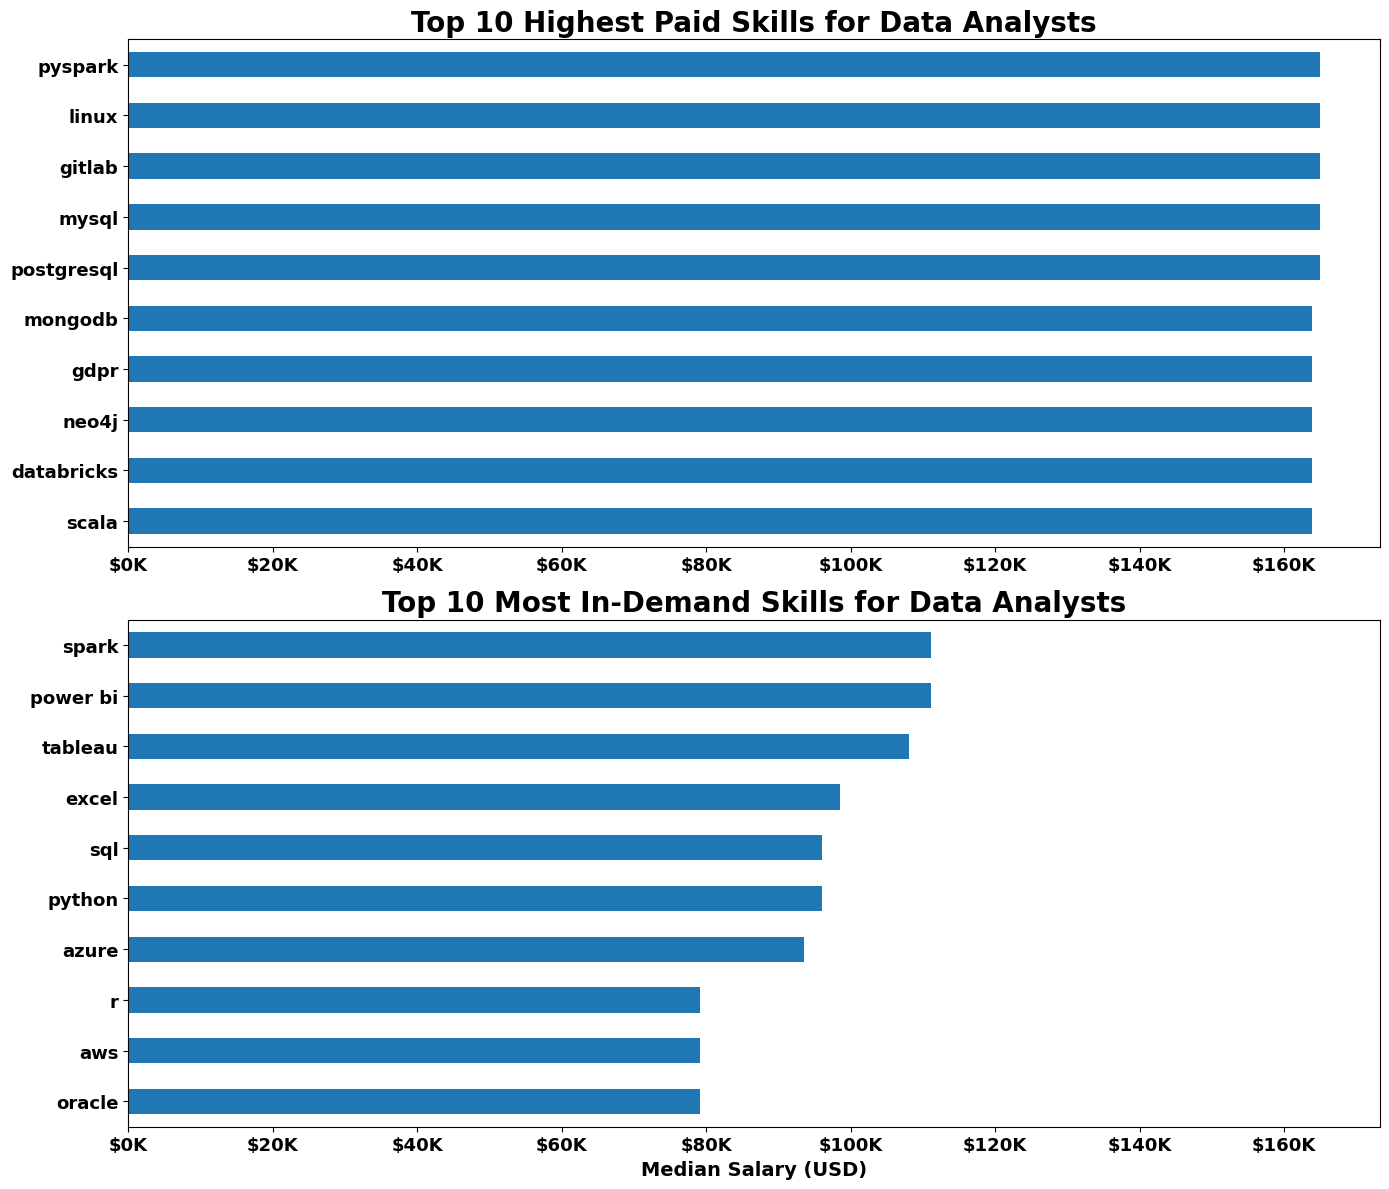

In [35]:
fig, ax = plt.subplots(2, 1, figsize=(14, 12))

df_DA_IND_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)

ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts',fontsize= 20, fontweight='bold')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


df_DA_IND_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)

ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts',fontsize= 20, fontweight='bold')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


ax[1].set_xlim(ax[0].get_xlim())

for i in [0, 1]:
    # X and Y tick size
    ax[i].tick_params(axis='x', labelsize=13)
    ax[i].tick_params(axis='y', labelsize=13)

    # Make tick labels bold
    for label in ax[i].get_xticklabels() + ax[i].get_yticklabels():
        label.set_fontweight('bold')

    # If you use axis labels later
    ax[i].xaxis.label.set_size(14)
    ax[i].yaxis.label.set_size(14)
    ax[i].xaxis.label.set_fontweight('bold')
    ax[i].yaxis.label.set_fontweight('bold')


fig.tight_layout()